# Module 2 — Part A: Exploratory Data Analysis

This notebook loads the Titanic dataset once, profiles it, handles missing
values according to the required threshold rule, performs univariate and
bivariate analysis, develops a multivariate data story, and saves the cleaned
dataset as `titanic.csv`.

The modeling notebook will continue from this same cleaned CSV.

In [2]:
import os
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

OUTPUT_DIR = "outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RANDOM_STATE = 42

In [3]:
df = sns.load_dataset("titanic")

print("Dataset loaded successfully.")
print(f"Shape: {df.shape}")

Dataset loaded successfully.
Shape: (891, 15)


In [4]:
df.to_csv("titanic.csv", index=False)

print("Initial Titanic dataset saved to titanic.csv")

Initial Titanic dataset saved to titanic.csv


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [6]:
df.describe(include="all")

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
count,891.000000,891.000000,891,714.000000,891.000000,891.000000,891.000000,889,891,891,891,203,889,891,891
unique,NaN,NaN,2,NaN,NaN,NaN,NaN,3,3,3,2,7,3,2,2
top,NaN,NaN,male,NaN,NaN,NaN,NaN,S,Third,man,True,C,Southampton,no,True
freq,NaN,NaN,577,NaN,NaN,NaN,NaN,644,491,537,537,59,644,549,537
mean,0.383838,2.308642,NaN,29.699118,0.523008,0.381594,32.204208,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,0.486592,0.836071,NaN,14.526497,1.102743,0.806057,49.693429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,1.000000,NaN,0.420000,0.000000,0.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,0.000000,2.000000,NaN,20.125000,0.000000,0.000000,7.910400,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,0.000000,3.000000,NaN,28.000000,0.000000,0.000000,14.454200,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,1.000000,3.000000,NaN,38.000000,1.000000,0.000000,31.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Shape:", df.shape)

Rows: 891
Columns: 15
Shape: (891, 15)


In [8]:
missing_summary = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percentage": df.isna().mean() * 100
})

missing_summary = missing_summary[
    missing_summary["missing_count"] > 0
].sort_values(
    "missing_percentage",
    ascending=False
)

missing_summary

,missing_count,missing_percentage
deck,688,77.216611
age,177,19.865320
embarked,2,0.224467
embark_town,2,0.224467


## Missing-Value Strategy

The required threshold rule is:

- Less than 5% missing → drop the affected rows.
- 5%–30% missing → impute the missing values.
- More than 30% missing → evaluate whether the column should be dropped or
  whether "missing" should be treated as its own category.

The measured percentages are displayed in the previous cell.

In [9]:
df_clean = df.copy()

# Calculate missing percentages
missing_pct = df_clean.isna().mean() * 100

print("Missing-value percentages before cleaning:")
print(
    missing_pct[missing_pct > 0]
    .sort_values(ascending=False)
    .round(2)
)

# 1. age: 5%–30% missing -> median imputation
if "age" in df_clean.columns and df_clean["age"].isna().any():
    df_clean["age"] = df_clean["age"].fillna(
        df_clean["age"].median()
    )

# 2. deck: >30% missing -> drop column
if "deck" in df_clean.columns:
    df_clean = df_clean.drop(columns=["deck"])

# 3. embarked: <5% -> drop affected rows
if "embarked" in df_clean.columns:
    df_clean = df_clean.dropna(subset=["embarked"])

# 4. embark_town: <5% -> drop affected rows
if "embark_town" in df_clean.columns:
    df_clean = df_clean.dropna(subset=["embark_town"])

print("\nShape after cleaning:", df_clean.shape)

print("\nRemaining missing values:")
print(df_clean.isna().sum()[df_clean.isna().sum() > 0])

Missing-value percentages before cleaning:
deck           77.22
age            19.87
embarked        0.22
embark_town     0.22
dtype: float64

Shape after cleaning: (889, 14)

Remaining missing values:
Series([], dtype: int64)


In [12]:
strategy_table = pd.DataFrame({
    "Column": ["age", "deck", "embarked", "embark_town"],
    "Strategy": [
        "Median imputation",
        "Drop column",
        "Drop rows",
        "Drop rows"
    ],
    "Reason": [
        "Missing percentage is between 5% and 30%",
        "Missing percentage is above 30%; imputation would be unreliable",
        "Missing percentage is below 5%",
        "Missing percentage is below 5%"
    ]
})

strategy_table

,Column,Strategy,Reason
0,age,Median imputation,Missing percentage is between 5% and 30%
1,deck,Drop column,Missing percentage is above 30%; imputation wo...
2,embarked,Drop rows,Missing percentage is below 5%
3,embark_town,Drop rows,Missing percentage is below 5%


### Cleaning Decisions

`age` is handled using median imputation because its missing rate falls
within the 5%–30% range.

`embarked` and `embark_town` have very small missing rates, so the affected
rows are removed according to the under-5% rule.

`deck` has a very high missing rate. Instead of creating a large amount of
imputed information, the column is removed because its missingness makes
reliable imputation inappropriate.

In [13]:
df = df_clean.copy()

df.to_csv("titanic.csv", index=False)

print("Cleaned dataset saved to analytics/titanic.csv")
print("Final shape:", df.shape)

Cleaned dataset saved to analytics/titanic.csv
Final shape: (889, 14)


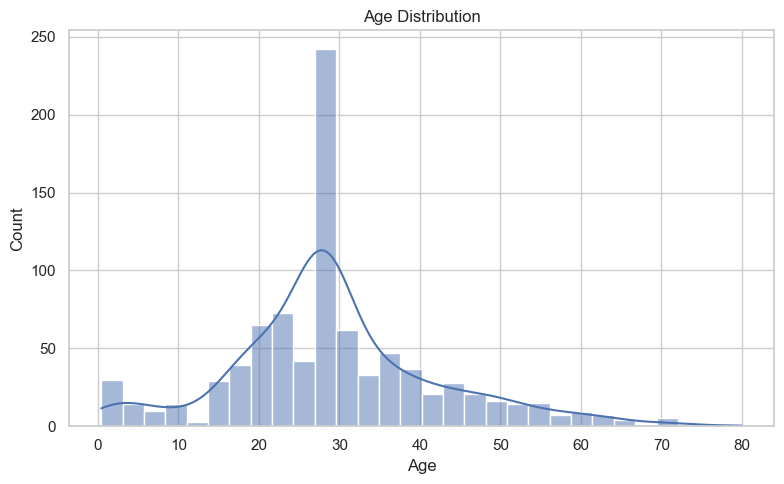

In [14]:
plt.figure(figsize=(8, 5))

sns.histplot(df["age"], kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "age_histogram.png"),
    dpi=150
)

plt.show()

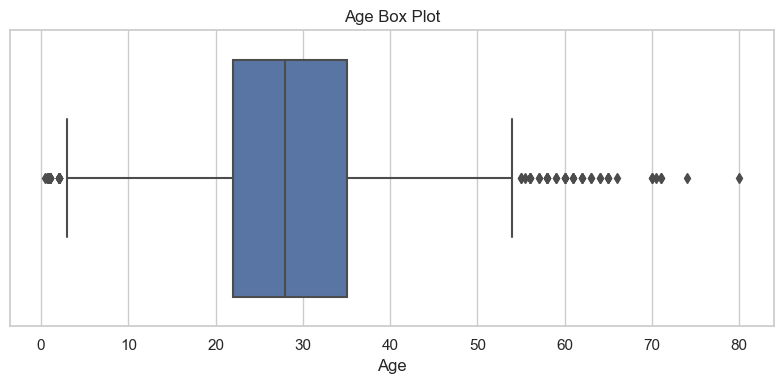

In [15]:
plt.figure(figsize=(8, 4))

sns.boxplot(x=df["age"])

plt.title("Age Box Plot")
plt.xlabel("Age")

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "age_boxplot.png"),
    dpi=150
)

plt.show()

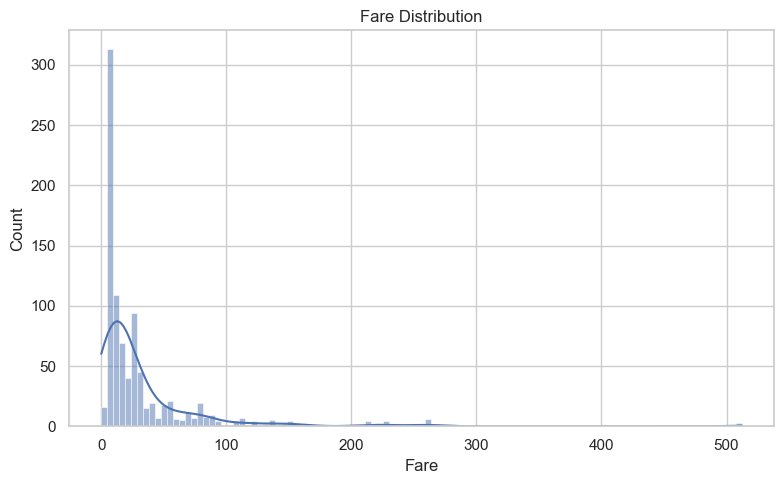

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(df["fare"], kde=True)

plt.title("Fare Distribution")
plt.xlabel("Fare")
plt.ylabel("Count")

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "fare_histogram.png"),
    dpi=150
)

plt.show()

In [17]:
def count_iqr_outliers(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)

    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = series[
        (series < lower_bound) |
        (series > upper_bound)
    ]

    return {
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": len(outliers)
    }


age_outliers = count_iqr_outliers(df["age"])
fare_outliers = count_iqr_outliers(df["fare"])

print("AGE OUTLIERS")
print(age_outliers)

print("\nFARE OUTLIERS")
print(fare_outliers)

AGE OUTLIERS
{'Q1': 22.0, 'Q3': 35.0, 'IQR': 13.0, 'lower_bound': 2.5, 'upper_bound': 54.5, 'outlier_count': 65}

FARE OUTLIERS
{'Q1': 7.8958, 'Q3': 31.0, 'IQR': 23.1042, 'lower_bound': -26.7605, 'upper_bound': 65.6563, 'outlier_count': 114}


In [18]:
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode().iloc[0]

print(f"Fare Mean   : {fare_mean:.2f}")
print(f"Fare Median : {fare_median:.2f}")
print(f"Fare Mode   : {fare_mode:.2f}")

Fare Mean   : 32.10
Fare Median : 14.45
Fare Mode   : 8.05


In [19]:
fare_skewness = df["fare"].skew()

print(f"Fare skewness: {fare_skewness:.4f}")

if fare_mean > fare_median > fare_mode:
    interpretation = "right-skewed"
elif fare_mean < fare_median < fare_mode:
    interpretation = "left-skewed"
else:
    interpretation = "approximately symmetric or not strictly ordered"

print("Distribution:", interpretation)

Fare skewness: 4.8014
Distribution: right-skewed


### Fare Distribution Interpretation

The mean, median, and mode are compared to determine the direction of skew.
The skewness statistic is also reported as supporting evidence.

In [20]:
survival_by_sex = (
    df.groupby("sex")["survived"]
      .mean()
      .mul(100)
      .round(2)
)

print("Survival rate by sex (%)")
print(survival_by_sex)

Survival rate by sex (%)
sex
female    74.04
male      18.89
Name: survived, dtype: float64


In [21]:
survival_by_pclass = (
    df.groupby("pclass")["survived"]
      .mean()
      .mul(100)
      .round(2)
)

print("Survival rate by passenger class (%)")
print(survival_by_pclass)

Survival rate by passenger class (%)
pclass
1    62.62
2    47.28
3    24.24
Name: survived, dtype: float64


In [22]:
groups = {
    "Female & First Class":
        (df["sex"] == "female") & (df["pclass"] == 1),

    "Female & Second Class":
        (df["sex"] == "female") & (df["pclass"] == 2),

    "Female & Third Class":
        (df["sex"] == "female") & (df["pclass"] == 3),

    "Male & First Class":
        (df["sex"] == "male") & (df["pclass"] == 1),

    "Male & Second Class":
        (df["sex"] == "male") & (df["pclass"] == 2),

    "Male & Third Class":
        (df["sex"] == "male") & (df["pclass"] == 3)
}

combined_survival = {}

for name, mask in groups.items():
    combined_survival[name] = df.loc[mask, "survived"].mean() * 100

combined_survival_df = pd.DataFrame(
    combined_survival.items(),
    columns=["Group", "Survival_Rate_Percent"]
)

combined_survival_df["Survival_Rate_Percent"] = (
    combined_survival_df["Survival_Rate_Percent"].round(2)
)

combined_survival_df

,Group,Survival_Rate_Percent
0,Female & First Class,96.74
1,Female & Second Class,92.11
2,Female & Third Class,50.00
3,Male & First Class,36.89
4,Male & Second Class,15.74
5,Male & Third Class,13.54


In [23]:
correlation_columns = [
    "survived",
    "pclass",
    "age",
    "sibsp",
    "parch",
    "fare"
]

corr_matrix = df[correlation_columns].corr()

corr_matrix

,survived,pclass,age,sibsp,parch,fare
survived,1.000000,-0.335549,-0.069822,-0.034040,0.083151,0.255290
pclass,-0.335549,1.000000,-0.336512,0.081656,0.016824,-0.548193
age,-0.069822,-0.336512,1.000000,-0.232543,-0.171485,0.093707
sibsp,-0.034040,0.081656,-0.232543,1.000000,0.414542,0.160887
parch,0.083151,0.016824,-0.171485,0.414542,1.000000,0.217532
fare,0.255290,-0.548193,0.093707,0.160887,0.217532,1.000000


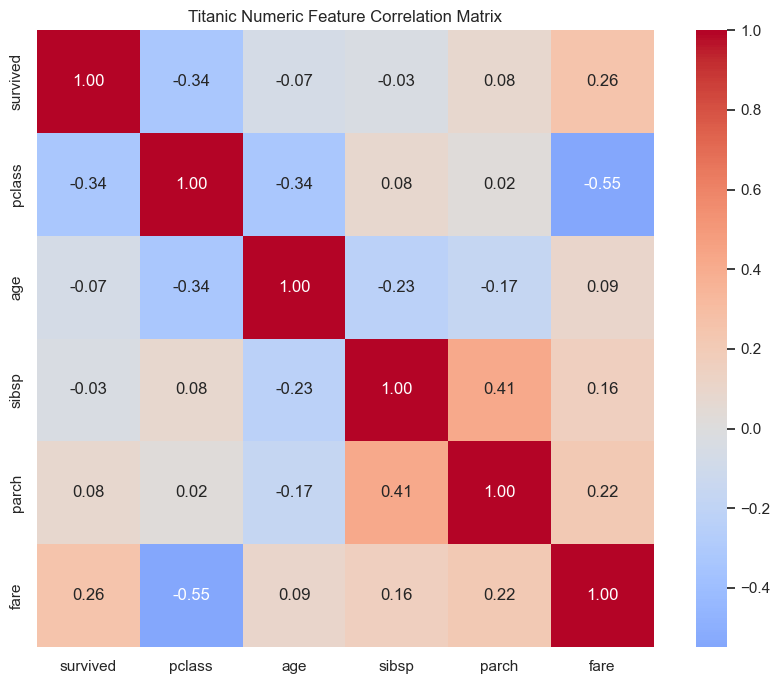

In [24]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True
)

plt.title("Titanic Numeric Feature Correlation Matrix")

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "correlation_heatmap.png"),
    dpi=150
)

plt.show()

In [ ]:
corr_pairs = (
    corr_matrix
    .where(
        np.triu(
            np.ones(corr_matrix.shape),
            k=1
        ).astype(bool)
    )
    .stack()
    .reset_index()
)

corr_pairs.columns = [
    "Feature_1",
    "Feature_2",
    "Correlation"
]

corr_pairs["Absolute_Correlation"] = (
    corr_pairs["Correlation"].abs()
)

strongest_two = (
    corr_pairs
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
    .head(2)
)




,Feature_1,Feature_2,Correlation,Absolute_Correlation
8,pclass,fare,-0.548193,0.548193
12,sibsp,parch,0.414542,0.414542


In [26]:
for _, row in strongest_two.iterrows():
    print(
        f"{row['Feature_1']} ↔ {row['Feature_2']}: "
        f"{row['Correlation']:.3f}"
    )

pclass ↔ fare: -0.548
sibsp ↔ parch: 0.415


### Interpretation of the Two Strongest Correlations

The strongest absolute correlation is between `pclass` and `fare`,
with a correlation of approximately -0.55. The negative relationship
occurs because lower numerical passenger-class values represent higher
classes, which generally have higher fares.

The second strongest correlation is between `sibsp` and `parch`,
with a correlation of approximately 0.41. This positive relationship
indicates that passengers traveling with siblings/spouses also tended
to have parents/children recorded in the dataset, reflecting family
travel patterns.

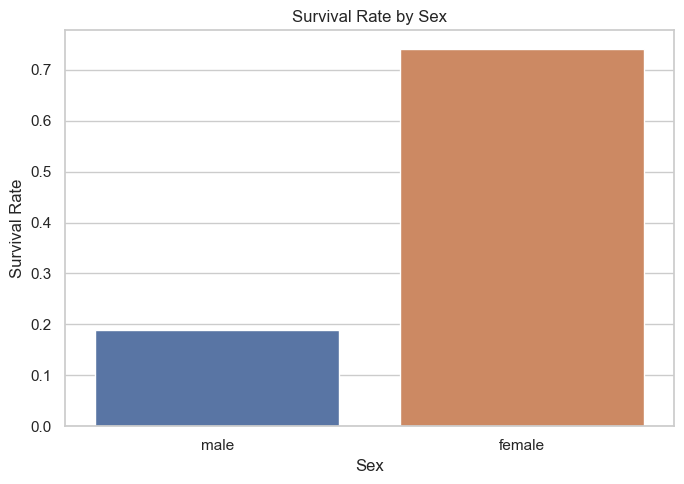

In [27]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="sex",
    y="survived",
    errorbar=None
)

plt.title("Survival Rate by Sex")
plt.ylabel("Survival Rate")
plt.xlabel("Sex")

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "survival_by_sex.png"),
    dpi=150
)

plt.show()

### Interpretation

This chart compares the survival rate between male and female passengers.
The difference shows that survival was associated with passenger sex in the
Titanic dataset. This relationship should be interpreted together with
passenger class and other characteristics rather than as an isolated cause.

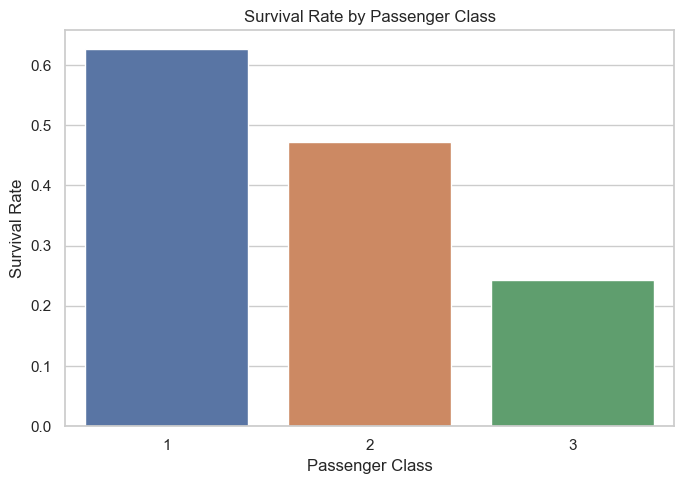

In [28]:
plt.figure(figsize=(7, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    errorbar=None
)

plt.title("Survival Rate by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "survival_by_pclass.png"),
    dpi=150
)

plt.show()

### Interpretation

Survival rates differ across passenger classes. This indicates that
passenger class is associated with survival in this dataset and provides
additional context when examining the effect of sex and age.

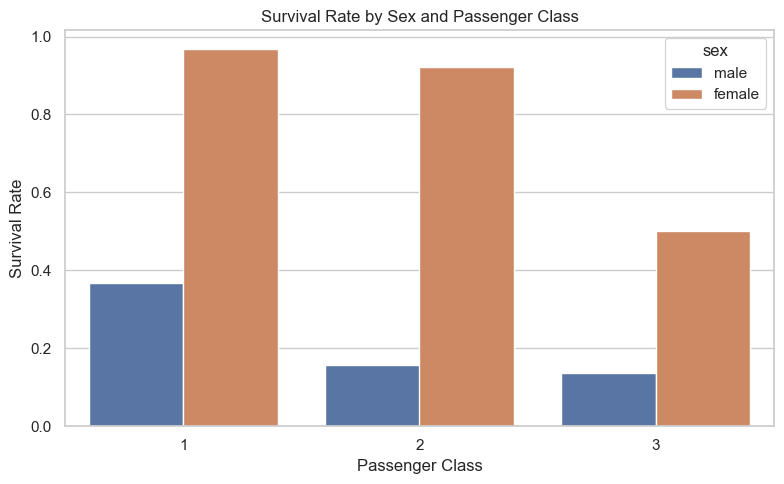

In [29]:
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="pclass",
    y="survived",
    hue="sex",
    errorbar=None
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Survival Rate")

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "survival_sex_pclass.png"),
    dpi=150
)

plt.show()

### Interpretation

The combined view shows how survival varies when sex and passenger class
are considered together. The chart helps reveal interaction patterns that
would not be visible from either variable independently.

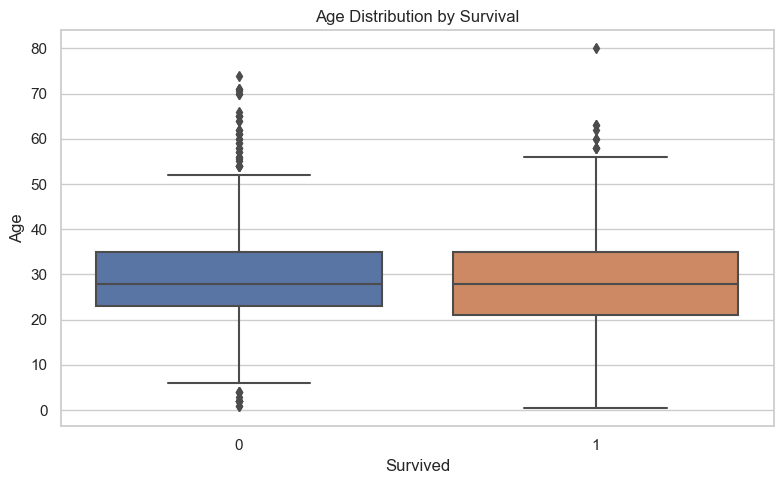

In [30]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="survived",
    y="age"
)

plt.title("Age Distribution by Survival")
plt.xlabel("Survived")
plt.ylabel("Age")

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "age_survival_boxplot.png"),
    dpi=150
)

plt.show()

### Interpretation

The age distributions of survivors and non-survivors can be compared using
their medians, spreads, and extreme observations. Age therefore provides
additional information that can complement the stronger categorical patterns
observed for sex and passenger class.

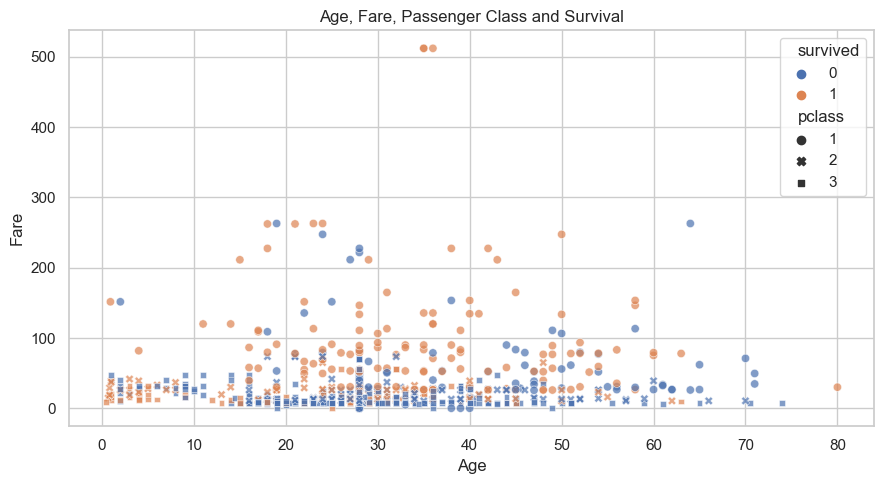

In [31]:
plt.figure(figsize=(9, 5))

sns.scatterplot(
    data=df,
    x="age",
    y="fare",
    hue="survived",
    style="pclass",
    alpha=0.7
)

plt.title("Age, Fare, Passenger Class and Survival")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.tight_layout()
plt.savefig(
    os.path.join(OUTPUT_DIR, "age_fare_survival.png"),
    dpi=150
)

plt.show()

### Interpretation

The scatter plot combines age, fare, passenger class, and survival to show
how several variables overlap. Higher fares are associated with particular
passenger classes, so fare should be interpreted alongside class rather than
as a completely independent measure of passenger status.

In [32]:
standardized_df = df.copy()

scaler = StandardScaler()

standardized_df[["age_z", "fare_z"]] = scaler.fit_transform(
    df[["age", "fare"]]
)

before_after = pd.DataFrame({
    "Feature": ["age", "fare"],
    "Before_Mean": [
        df["age"].mean(),
        df["fare"].mean()
    ],
    "Before_Std": [
        df["age"].std(),
        df["fare"].std()
    ],
    "After_Mean": [
        standardized_df["age_z"].mean(),
        standardized_df["fare_z"].mean()
    ],
    "After_Std": [
        standardized_df["age_z"].std(),
        standardized_df["fare_z"].std()
    ]
})

before_after.round(4)

,Feature,Before_Mean,Before_Std,After_Mean,After_Std
0,age,29.3152,12.9849,0.0,1.0006
1,fare,32.0967,49.6975,0.0,1.0006


### Standardization Interpretation

The standardized versions of `age` and `fare` have means approximately equal
to zero and standard deviations approximately equal to one. This is only an
EDA-stage sanity check; these transformed columns are not used as the
classification modeling input. The modeling pipeline performs its own
training-only scaling.